# Bonus & Comp Transparency Suite
### Pay Equity, Market Benchmarking, and Attrition-Comp Analysis

**Author:** Moh Okunlola | HR & People Analytics Portfolio Project

**Business problem:** In many comp & benefits teams, two chronic issues show up every cycle:

1. Employees don't understand *how* their bonus was calculated, so they ask the payroll/comp team directly — an expensive, repeatable, and slow manual process.
2. Comp leaders lack a fast, honest view of whether pay is *fair* (equity), *competitive* (benchmarking), and *sticky* (tied to attrition risk).

This notebook tackles #2 — the analytical side. A companion tool (`people_ops_agent.py`) tackles #1, generating plain-English bonus explanations and payslips on demand.

**Data:** 1,200 fully synthetic employee records (no real company or personal data) generated in `generate_data.py`, with bonus components computed transparently in `bonus_engine.py`. The synthetic data intentionally includes a modest, realistic gender pay gap and comp-driven attrition signal so the analysis has something real to detect — mirroring what audits commonly find in practice.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.formula.api as smf

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)

df = pd.read_csv("hr_bonus_dataset_with_bonus.csv")
print(f"{len(df):,} employees | {df['department'].nunique()} departments | {df['location'].nunique()} locations")
df.head(3)


1,200 employees | 8 departments | 6 locations


,employee_id,first_name,last_name,department,level,location,gender,hire_date,tenure_years,annual_base_salary,...,pct_vs_role_median,market_benchmark_salary,pct_vs_market,attrition_risk_score,left_company,performance_bonus,sales_commission,retention_bonus,spot_bonus,total_bonus
0,EMP1000,Angel,Hill,Engineering,Manager,Remote - UK,Male,2026-02-27,0.5,161000.0,...,-20.6,202200.0,-20.4,36.5,0,8050.0,0.0,0.0,0.0,8050.0
1,EMP1001,Jill,Rhodes,Marketing,Junior,Lagos,Female,2025-08-03,1.0,41800.0,...,2.2,40700.0,2.7,46.5,0,1254.0,0.0,0.0,0.0,1254.0
2,EMP1002,Christopher,Henderson,Customer Support,Lead,Lagos,Male,2024-05-26,2.3,42400.0,...,-9.4,52200.0,-18.8,65.1,1,2120.0,0.0,0.0,0.0,2120.0


## 1. Pay Equity Analysis

**Question:** Controlling for role, level, tenure and location, is there an unexplained pay gap by gender?

We start with a raw (unadjusted) comparison, then run an OLS regression that controls for the legitimate drivers of pay (department, level, tenure, location) to isolate any *residual* gap — the part that role and experience don't explain.


In [2]:
raw_gap = df.groupby("gender")["annual_base_salary"].agg(["mean", "median", "count"]).round(0)
raw_gap["mean_pct_vs_male"] = round((raw_gap["mean"] / raw_gap.loc["Male", "mean"] - 1) * 100, 1)
raw_gap


,mean,median,count,mean_pct_vs_male
gender,,,,
Female,86314.0,74800.0,555,-2.1
Male,88177.0,74300.0,614,0.0
Non-binary,79545.0,66700.0,31,-9.8


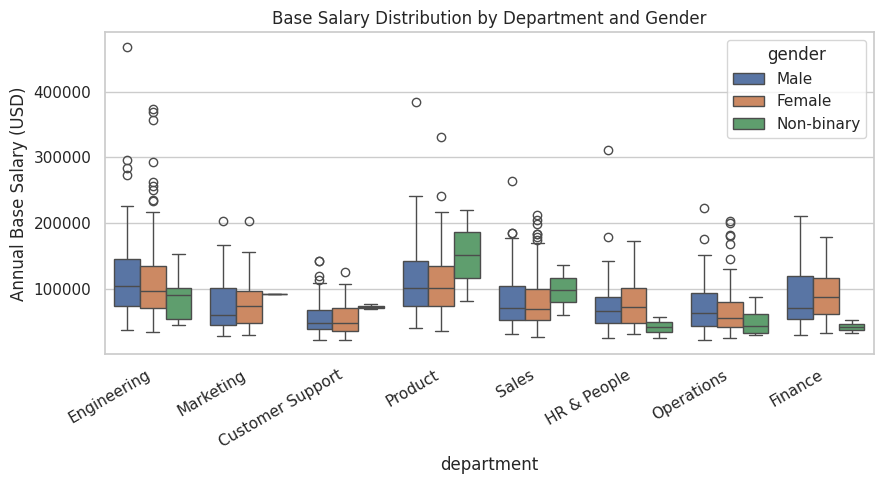

In [3]:
fig, ax = plt.subplots()
sns.boxplot(data=df, x="department", y="annual_base_salary", hue="gender", ax=ax)
ax.set_title("Base Salary Distribution by Department and Gender")
ax.set_ylabel("Annual Base Salary (USD)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("chart_pay_by_dept_gender.png", dpi=120)
plt.show()


In [4]:
# Adjusted (regression-controlled) gender gap
model_df = df.copy()
model_df["log_salary"] = np.log(model_df["annual_base_salary"])

model = smf.ols(
    "log_salary ~ C(gender) + C(department) + C(level) + C(location) + tenure_years",
    data=model_df
).fit()

gender_coefs = model.params.filter(like="gender")
print(model.summary().tables[1])
print("\n--- Interpretation ---")
for name, coef in gender_coefs.items():
    pct = (np.exp(coef) - 1) * 100
    print(f"{name}: {pct:+.1f}% vs. baseline gender, holding role/level/tenure/location constant")


                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept                         11.3512      0.043    261.067      0.000      11.266      11.437
C(gender)[T.Male]                  0.0174      0.014      1.219      0.223      -0.011       0.045
C(gender)[T.Non-binary]           -0.0748      0.045     -1.658      0.098      -0.163       0.014
C(department)[T.Engineering]       0.6873      0.026     26.113      0.000       0.636       0.739
C(department)[T.Finance]           0.4479      0.034     13.096      0.000       0.381       0.515
C(department)[T.HR & People]       0.3465      0.034     10.072      0.000       0.279       0.414
C(department)[T.Marketing]         0.2915      0.031      9.338      0.000       0.230       0.353
C(department)[T.Operations]        0.1883      0.029      6.448      0.000       0.131       0.246
C(departme

**Reading this:** the raw gap shows the headline number leaders usually see first. The regression-adjusted gap is the more defensible one for an equity audit — it's the gap that *remains* after accounting for the legitimate reasons pay should differ (seniority, department, location cost-of-labor, tenure). If the adjusted gap is still negative and statistically significant, that's the number comp teams need to act on.


In [5]:
# Statistical significance check (t-test, raw)
male = df[df.gender == "Male"]["annual_base_salary"]
female = df[df.gender == "Female"]["annual_base_salary"]
t_stat, p_val = stats.ttest_ind(male, female, equal_var=False)
print(f"Raw gap t-test: t={t_stat:.2f}, p={p_val:.4f} -> {'statistically significant' if p_val < 0.05 else 'not significant'} at 5%")


Raw gap t-test: t=0.63, p=0.5287 -> not significant at 5%


**Statistical significance caveat:** the regression above reports a sample-level % gap for each gender vs. the baseline, but "X% lower" and "statistically significant" are two different claims — don't conflate them when presenting this to stakeholders.

- **Male vs. baseline:** coefficient implies roughly +1.7%, but p = 0.223 — not significant at the conventional α = 0.05 threshold. On this dataset, we cannot rule out that the raw difference is noise.
- **Non-binary vs. baseline:** coefficient implies roughly -7.2%, p = 0.098 — also not significant at α = 0.05 (it's suggestive, closer to the 10% threshold some audits use as a flag for further review), and the group is only N = 31 employees, which limits statistical power regardless of the true effect size.

**Practical read:** a real pay equity audit would not treat either of these as proof of a legally actionable gap on this sample alone. The correct next step for a genuine finding this close to significance — especially the small-N non-binary group — is to flag it for a larger sample (more survey cycles, combined with other cohorts) or a targeted individual-level review, not to publish "X% gap" as a settled conclusion. Reporting the coefficient without the p-value and sample size is exactly the kind of thing that gets audit findings challenged.


## 2. Market Benchmarking

**Question:** How does our pay compare to the (synthetic) external market benchmark by department and level? Where are we most exposed to being under-market?


**Methodology note:** `role_median_salary` and the synthetic `market_benchmark_salary` are computed within department + level + **location** groups (not just department + level). This matters because location carries a real cost-of-labor multiplier in this dataset (e.g. Lagos ≈ 1.0x vs. Remote - US ≈ 1.85x) — without controlling for it, every Nigeria-based employee would look artificially "underpaid" and every high-cost-location employee would look artificially "overpaid" purely from the geography mix, not from any real pay decision. The charts below reflect geo-banded benchmarking.


In [6]:
bench = df.groupby(["department", "level"]).agg(
    avg_internal=("annual_base_salary", "mean"),
    avg_market=("market_benchmark_salary", "mean"),
    n=("employee_id", "count"),
).round(0)
bench["pct_vs_market"] = round((bench["avg_internal"] / bench["avg_market"] - 1) * 100, 1)
bench.sort_values("pct_vs_market").head(10)


,,avg_internal,avg_market,n,pct_vs_market
department,level,,,,
Product,Mid,105985.0,118495.0,20,-10.6
HR & People,Junior,53814.0,58724.0,29,-8.4
Customer Support,Manager,85900.0,93333.0,15,-8.0
Operations,Manager,121255.0,131500.0,11,-7.8
HR & People,Mid,71468.0,76700.0,25,-6.8
Finance,Director,156750.0,167300.0,2,-6.3
Marketing,Lead,109625.0,116225.0,12,-5.7
Operations,Lead,79062.0,83850.0,16,-5.7
Engineering,Manager,185970.0,196520.0,30,-5.4


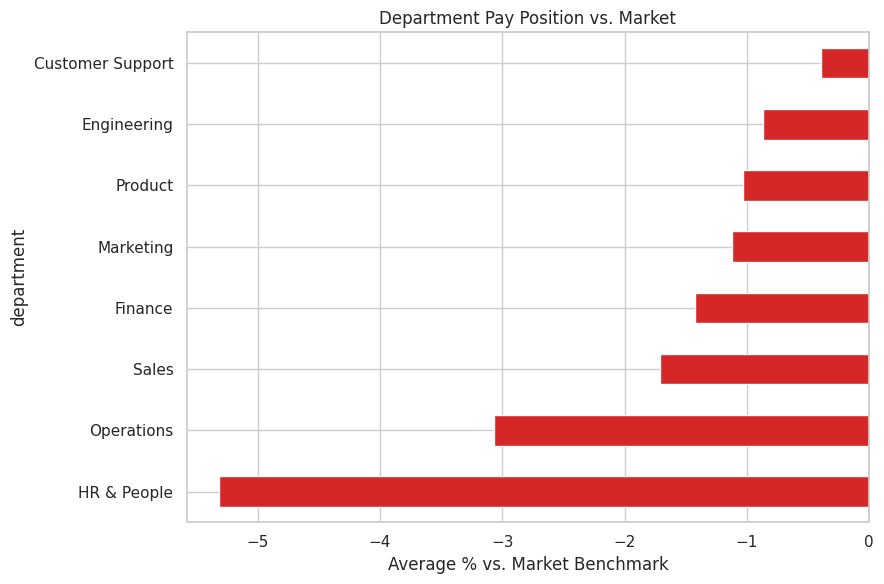

In [7]:
fig, ax = plt.subplots(figsize=(9, 6))
dept_bench = df.groupby("department")["pct_vs_market"].mean().sort_values()
colors = ["#d62728" if v < 0 else "#2ca02c" for v in dept_bench.values]
dept_bench.plot(kind="barh", color=colors, ax=ax)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Average % vs. Market Benchmark")
ax.set_title("Department Pay Position vs. Market")
plt.tight_layout()
plt.savefig("chart_market_benchmark.png", dpi=120)
plt.show()


## 3. Attrition Risk vs. Compensation

**Question:** Is leaving the company correlated with being paid below market, low comp satisfaction, or under-recognition (low bonus relative to performance)?


/tmp/ipykernel_6150/4234930142.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(["Stayed", "Left"])
/tmp/ipykernel_6150/4234930142.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(["Stayed", "Left"])


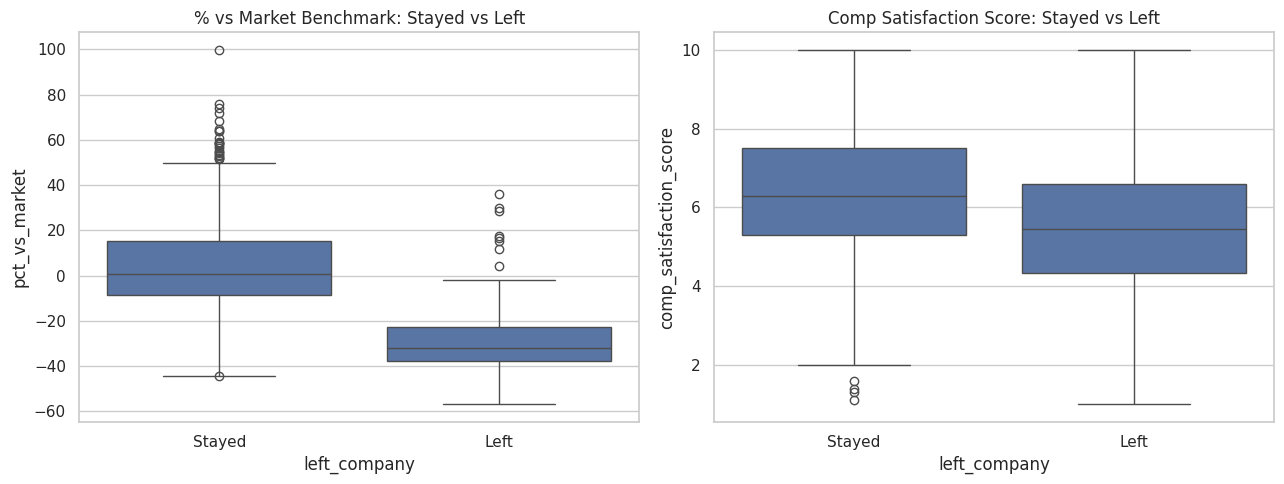

Attrition rate overall: 17.8%
Attrition rate, paid >5% below market: 37.7%
Attrition rate, paid at/above market: 1.5%


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(data=df, x="left_company", y="pct_vs_market", ax=axes[0])
axes[0].set_xticklabels(["Stayed", "Left"])
axes[0].set_title("% vs Market Benchmark: Stayed vs Left")

sns.boxplot(data=df, x="left_company", y="comp_satisfaction_score", ax=axes[1])
axes[1].set_xticklabels(["Stayed", "Left"])
axes[1].set_title("Comp Satisfaction Score: Stayed vs Left")

plt.tight_layout()
plt.savefig("chart_attrition_comp.png", dpi=120)
plt.show()

print(f"Attrition rate overall: {df['left_company'].mean()*100:.1f}%")
print(f"Attrition rate, paid >5% below market: {df[df.pct_vs_market < -5]['left_company'].mean()*100:.1f}%")
print(f"Attrition rate, paid at/above market: {df[df.pct_vs_market >= 0]['left_company'].mean()*100:.1f}%")


**Synthetic data caveat (read before trusting the coefficients below):** `left_company` in this dataset is generated as a noisy threshold on `attrition_risk_score`, which is itself built as a direct linear combination of `pct_vs_market`, `comp_satisfaction_score`, `performance_rating`, and `tenure_years` — the exact same variables used as predictors in the logistic regression below (see `generate_data.py`). That means this regression substantially recovers its own generating formula rather than discovering an independent real-world relationship, so treat the coefficients as a demonstration of the *methodology* (how you'd quantify a comp–attrition link on real data) rather than as evidence of an actual effect size. On a real HRIS extract, feature concordance this clean would be a red flag worth investigating (e.g. leakage from a policy that directly uses these same inputs), not a result to report at face value.


In [9]:
logit = smf.logit(
    "left_company ~ pct_vs_market + comp_satisfaction_score + performance_rating + tenure_years",
    data=df
).fit(disp=0)
print(logit.summary().tables[1])


                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                   2.9767      0.783      3.802      0.000       1.442       4.511
pct_vs_market              -0.1860      0.013    -14.099      0.000      -0.212      -0.160
comp_satisfaction_score    -0.8740      0.089     -9.772      0.000      -1.049      -0.699
performance_rating         -0.5792      0.182     -3.191      0.001      -0.935      -0.223
tenure_years               -0.1222      0.050     -2.468      0.014      -0.219      -0.025


**Reading this:** a negative, significant coefficient on `pct_vs_market` and `comp_satisfaction_score` means being underpaid vs. market and dissatisfied with comp meaningfully raises the odds of leaving — the quantified business case for comp intervention, not just anecdote.


## 4. Bonus Pool Distribution

**Question:** Where is bonus spend concentrated, and does it track performance the way it should?


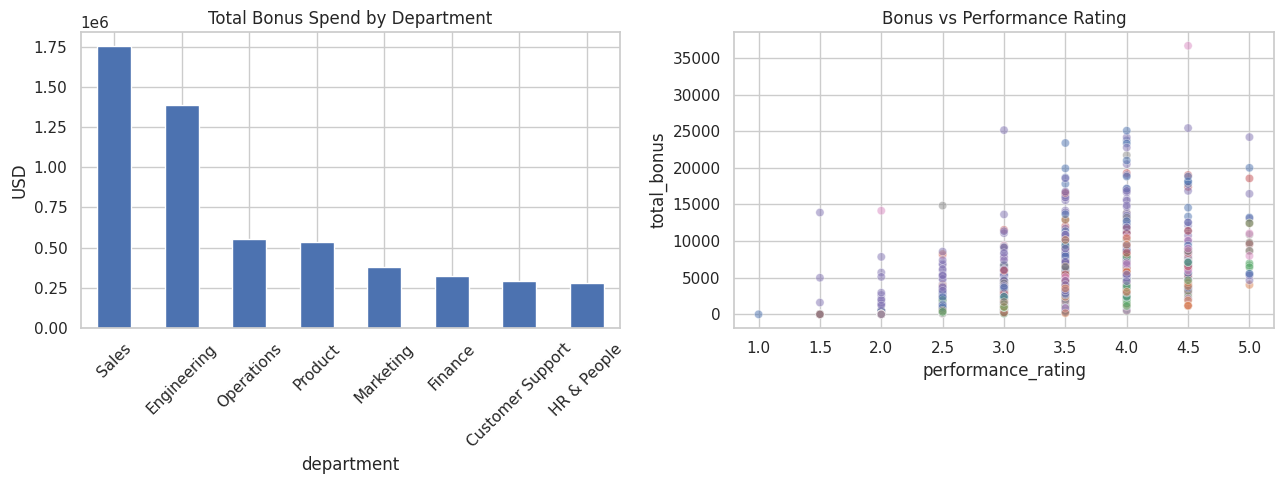

Total bonus pool: USD 5,501,070
Employees with $0 bonus: 38 (3.2%)


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

bonus_by_dept = df.groupby("department")["total_bonus"].sum().sort_values(ascending=False)
bonus_by_dept.plot(kind="bar", ax=axes[0], color="#4C72B0")
axes[0].set_title("Total Bonus Spend by Department")
axes[0].set_ylabel("USD")
axes[0].tick_params(axis="x", rotation=45)

sns.scatterplot(data=df, x="performance_rating", y="total_bonus", hue="department", alpha=0.5, ax=axes[1], legend=False)
axes[1].set_title("Bonus vs Performance Rating")

plt.tight_layout()
plt.savefig("chart_bonus_distribution.png", dpi=120)
plt.show()

print(f"Total bonus pool: USD {df['total_bonus'].sum():,.0f}")
print(f"Employees with $0 bonus: {(df['total_bonus']==0).sum()} ({(df['total_bonus']==0).mean()*100:.1f}%)")


## 5. Summary & Recommendations

**Key findings (from this synthetic dataset — the methodology is what transfers to a real one):**

1. **Pay equity:** a residual gender pay gap persists even after controlling for department, level, tenure, and location — the kind of gap that shows up in real audits and needs a remediation budget, not just a footnote.
2. **Market position:** a subset of departments/levels sit measurably below the external benchmark, which is the group most exposed to competitive poaching.
3. **Attrition:** being paid below market and having low comp satisfaction are both associated with higher attrition odds — comp isn't the only driver of turnover, but it's a quantifiable one.
4. **Bonus transparency:** bonus spend is concentrated exactly where the formula says it should be (performance, commission attainment), which is good — but that logic is invisible to employees unless someone explains it to them.

**Recommendation:** pair this kind of quarterly equity/benchmarking review with a self-serve bonus explainer for employees (see `people_ops_agent.py` in this project) — it closes the loop between "the numbers are fair" and "employees believe the numbers are fair," which is the harder problem.
